In [140]:
import pandas as pd
import os
import sys

In [ ]:
SSD_path = '../../../../../Volumes/SSD_01/'

mrkr_data_path ='../../../../../Volumes/HDD_02/datasets/emory_mrkr/'
mrkr_data_path = os.path.abspath(mrkr_data_path)
mrkr_tables_path = os.path.join(mrkr_data_path,'tables')

table_names = os.listdir(mrkr_tables_path)

image_df = pd.read_csv(
    os.path.join(
        mrkr_tables_path,
        table_names[-3]
    )
)

demo_df = pd.read_csv(
    os.path.join(
        mrkr_tables_path,
        table_names[-4]
    )
)

lateral_master_csv = os.path.join(mrkr_data_path, 'tables', 'lateral_master_df.csv')

if os.path.exists(lateral_master_csv):
    lateral_master_df = pd.read_csv(lateral_master_csv)
else:
    # build from image_df as before
    lateral_master_df = image_df[image_df.view_position == 'L'].reset_index(drop=True)
    lateral_master_df['mask_path'] = lateral_master_df['dicom_path'].apply(build_mask_path)
    lateral_master_df['is_segmented'] = False
    lateral_master_df.to_csv(lateral_master_csv, index=False)


In [7]:
table_names

['MRKR_ICD_dictionary.csv',
 'MRKR_pain.csv',
 'MRKR_ICD.csv',
 'MRKR_demographics.csv',
 'MRKR_image_metadata.csv',
 'MRKR_CPT_dictionary.csv',
 'MRKR_CPT.csv']

In [12]:
img_df.head()

,empi_anon,StudyInstanceUID_anon,SeriesInstanceUID_anon,SOPInstanceUID_anon,img_height,img_width,laterality,view_position,horizontal_flip,weight_bearing,inverted,arthroplasty,L_KLG_inference,R_KLG_inference,SeriesDescription,StudyDescription,StudyDate_anon,age_at_exam,dicom_path
0,10001182,1.2.849.113972.3.57.1.62631357.20201023.1122916,1.2.840.113570.163246170217.20201019125748437223,1.2.826.0.1.3680043.8.498.40281381358579896373...,2539.0,2079.0,R,L,0.0,1.0,0,0,NaN,NaN,LATERAL,XR Knee 3 Views Right Standard Protocol,2020-05-24,62,10001182/1.2.849.113972.3.57.1.62631357.202010...
1,10001758,1.2.840.113975.3.59.1.64324621.20210625.1133227,1.2.842.113572.163246212233.20210618135511646926,1.2.826.0.1.3680043.8.498.73756677603175613024...,2589.0,1820.0,R,L,0.0,0.0,0,0,NaN,NaN,Lateral,XR Knee 3 Views Right Standard Protocol,2021-08-06,41,10001758/1.2.840.113975.3.59.1.64324621.202106...
2,10002144,1.2.846.113977.3.58.1.56999138.20180517.1095048,1.2.846.113622.2.70.2207549553.205161805101005...,1.2.826.0.1.3680043.8.498.13086143241040152779...,1774.0,1045.0,R,I,0.0,0.0,0,0,NaN,NaN,XR Knee 3 Views Bilateral,XR KNEE 3 VIEWS BILATERAL,2018-02-13,40,10002144/1.2.846.113977.3.58.1.56999138.201805...
3,10002144,1.2.846.113977.3.58.1.56999138.20180517.1095048,1.2.846.113622.2.70.2207549553.205161805101005...,1.2.826.0.1.3680043.8.498.13222315862241217925...,1774.0,1045.0,R,F,0.0,0.0,0,0,NaN,NaN,XR Knee 3 Views Bilateral,XR KNEE 3 VIEWS BILATERAL,2018-02-13,40,10002144/1.2.846.113977.3.58.1.56999138.201805...
4,10002144,1.2.846.113977.3.58.1.56999138.20180517.1095048,1.2.846.113622.2.70.2207549553.205161805101005...,1.2.826.0.1.3680043.8.498.15405157314397326116...,1774.0,1044.0,L,F,0.0,0.0,0,0,NaN,NaN,XR Knee 3 Views Bilateral,XR KNEE 3 VIEWS BILATERAL,2018-02-13,40,10002144/1.2.846.113977.3.58.1.56999138.201805...


In [18]:
master_df = pd.merge(img_df, demo_df, how='left', on='empi_anon')

In [36]:
lateral_master_df = master_df[master_df.view_position == 'L']

In [37]:
lateral_master_df.head()

,empi_anon,StudyInstanceUID_anon,SeriesInstanceUID_anon,SOPInstanceUID_anon,img_height,img_width,laterality,view_position,horizontal_flip,weight_bearing,...,L_KLG_inference,R_KLG_inference,SeriesDescription,StudyDescription,StudyDate_anon,age_at_exam,dicom_path,sex,race,ethnicity
0,10001182,1.2.849.113972.3.57.1.62631357.20201023.1122916,1.2.840.113570.163246170217.20201019125748437223,1.2.826.0.1.3680043.8.498.40281381358579896373...,2539.0,2079.0,R,L,0.0,1.0,...,NaN,NaN,LATERAL,XR Knee 3 Views Right Standard Protocol,2020-05-24,62,10001182/1.2.849.113972.3.57.1.62631357.202010...,Male,Unknown,Unknown
1,10001758,1.2.840.113975.3.59.1.64324621.20210625.1133227,1.2.842.113572.163246212233.20210618135511646926,1.2.826.0.1.3680043.8.498.73756677603175613024...,2589.0,1820.0,R,L,0.0,0.0,...,NaN,NaN,Lateral,XR Knee 3 Views Right Standard Protocol,2021-08-06,41,10001758/1.2.840.113975.3.59.1.64324621.202106...,Female,Multiple,Unknown
6,10002144,1.2.846.113977.3.58.1.56999138.20180517.1095048,1.2.846.113622.2.70.2207549553.205161805101005...,1.2.826.0.1.3680043.8.498.25097243441976964330...,1775.0,1059.0,R,L,0.0,0.0,...,NaN,NaN,XR Knee 3 Views Bilateral,XR KNEE 3 VIEWS BILATERAL,2018-02-13,40,10002144/1.2.846.113977.3.58.1.56999138.201805...,Female,Caucasian or White,Non-Hispanic or Latino
7,10002144,1.2.846.113977.3.58.1.56999138.20180517.1095048,1.2.846.113622.2.70.2207549553.205161805101005...,1.2.826.0.1.3680043.8.498.73980548070501957600...,1771.0,1058.0,L,L,0.0,0.0,...,NaN,NaN,XR Knee 3 Views Bilateral,XR KNEE 3 VIEWS BILATERAL,2018-02-13,40,10002144/1.2.846.113977.3.58.1.56999138.201805...,Female,Caucasian or White,Non-Hispanic or Latino
9,10003180,1.2.845.113979.3.64.1.55016411.20170539.1,1.2.846.113564.1632467445.20170530081259855397,1.2.826.0.1.3680043.8.498.12678074990125916447...,2517.0,1985.0,R,L,0.0,1.0,...,NaN,NaN,LATERAL,XR Knee 3 Views Right Standard Protocol,2017-11-09,67,10003180/1.2.845.113979.3.64.1.55016411.201705...,Female,Caucasian or White,Non-Hispanic or Latino


### Setup (once)

1. Run Cell 1 — define paths, add mask_path column to lateral_master_df

### Each segmentation session (repeat until done)

2. Run Cell 2 — check status (how many segmented vs not)
3. Run Cell 3 — copy next batch of unsegmented DICOMs to SSD
4. Open 3D Slicer → segment tibia, femur, patella → save each mask as <stem>.nrrd to SSD/masks/
5. Run Cell 4 — copy masks HDD, verify, delete from SSD, refresh is_segmented

### Once enough masks collected (20–100)

6. Train segmentation model on annotated subset
7. Run inference on remaining 183k images → pseudo-labels
8. (Optional) Active learning — correct uncertain predictions, retrain

### Per image downstream pipeline

9. Load DICOM + mask via KneeDataset
10. Solve Laplace/Eikonal on tibia mask → intrinsic coordinate field
11. Compute posterior tibial slope from coordinate system
12. Store results back to lateral_master_df

In [2]:
# Cell 1

import shutil, os
import pandas as pd


SSD_path = '../../../../../Volumes/SSD_01/'
mrkr_data_path ='../../../../../Volumes/HDD_02/datasets/emory_mrkr/'

mrkr_data_path = os.path.abspath(mrkr_data_path)
SSD_path = os.path.abspath(SSD_path)

SSD_xray_path = os.path.join(SSD_path,'knee-landmarks-xray','temp')


SSD_dicom_dir = os.path.join(SSD_xray_path, 'images')
SSD_mask_dir  = os.path.join(SSD_xray_path, 'masks')
HDD_mask_dir  = os.path.join(mrkr_data_path, 'masks')

os.makedirs(SSD_dicom_dir, exist_ok=True)
os.makedirs(SSD_mask_dir,  exist_ok=True)
os.makedirs(HDD_mask_dir,  exist_ok=True)

def build_mask_path(dicom_path):
    stem = os.path.splitext(os.path.basename(dicom_path))[0]
    return os.path.join(HDD_mask_dir, f"{stem}.nrrd")


mrkr_tables_path = os.path.join(mrkr_data_path,'tables')

table_names = os.listdir(mrkr_tables_path)
table_names = os.listdir(mrkr_tables_path)

image_df = pd.read_csv(
    os.path.join(
        mrkr_tables_path,
        table_names[-3]
    )
)

demo_df = pd.read_csv(
    os.path.join(
        mrkr_tables_path,
        table_names[-4]
    )
)

lateral_master_csv = os.path.join(mrkr_data_path, 'tables', 'mrkrk_lateral_image_metadata.csv')

if os.path.exists(lateral_master_csv):
    lateral_master_df = pd.read_csv(lateral_master_csv)
else:
    # build from image_df as before
    lateral_master_df = image_df[image_df.view_position == 'L'].reset_index(drop=True)
    lateral_master_df['mask_path'] = lateral_master_df['dicom_path'].apply(build_mask_path)
    lateral_master_df['is_segmented'] = False
    lateral_master_df.to_csv(lateral_master_csv, index=False)


lateral_master_df['mask_path'] = lateral_master_df['dicom_path'].apply(build_mask_path)

lateral_master_df.to_csv(os.path.join(mrkr_data_path, 'tables', 'mrkrk_lateral_image_metadata.csv'), index=False)

In [66]:
lateral_master_df.loc[lateral_master_df.arthroplasty != '0','is_segmented'] = False

In [ ]:
lateral_master_df.loc[lateral_master_df['is_segmented'] == True]

In [69]:
lateral_master_df.loc[lateral_master_df['is_segmented'] == True]

,empi_anon,StudyInstanceUID_anon,SeriesInstanceUID_anon,SOPInstanceUID_anon,img_height,img_width,laterality,view_position,horizontal_flip,weight_bearing,...,arthroplasty,L_KLG_inference,R_KLG_inference,SeriesDescription,StudyDescription,StudyDate_anon,age_at_exam,dicom_path,mask_path,is_segmented
3292,11477472,1.2.846.113971.3.61.1.52569475.20160229.1084612,1.2.393.200038.9130.3.13681251112109199.648034...,1.2.826.0.1.3680043.8.498.80169779566077780281...,3015.0,2505.0,L,L,0.0,0.0,...,0,NaN,NaN,NaN,XR Knee 3 Views Left Standard Protocol,2016-04-28,29,11477472/1.2.846.113971.3.61.1.52569475.201602...,/Volumes/HDD_02/datasets/emory_mrkr/masks/1.2....,True
3293,11477472,1.2.848.113970.3.65.1.53689390.20160935.1082505,1.2.392.200040.9129.3.104520250195256.64822408...,1.2.826.0.1.3680043.8.498.69233584464990059189...,3015.0,2505.0,R,L,0.0,0.0,...,0,NaN,NaN,NaN,XR Knee 3 Views Right Standard Protocol,2016-11-30,29,11477472/1.2.848.113970.3.65.1.53689390.201609...,/Volumes/HDD_02/datasets/emory_mrkr/masks/1.2....,True
4937,12167417,1.2.396.200037.9127.2.8116247180152.6449244635...,1.2.392.200041.9127.3.8116247180152.6449244635...,1.2.826.0.1.3680043.8.498.27435865774109492731...,1976.0,1576.0,R,L,0.0,0.0,...,0,NaN,NaN,NaN,XR KNEE 1 OR 2 VIEWS HIST,2006-11-01,59,12167417/1.2.396.200037.9127.2.8116247180152.6...,/Volumes/HDD_02/datasets/emory_mrkr/masks/1.2....,True
4938,12167417,1.2.845.113977.3.62.1.53725549.20161013.1211544,1.2.841.113571.1632466546.201610042126471570,1.2.826.0.1.3680043.8.498.30380192832491223693...,2143.0,1633.0,L,L,0.0,0.0,...,0,NaN,NaN,LATERAL,XR Knee 3 Views Left Standard Protocol,2017-02-13,70,12167417/1.2.845.113977.3.62.1.53725549.201610...,/Volumes/HDD_02/datasets/emory_mrkr/masks/1.2....,True
4939,12167417,1.2.847.113971.3.61.1.53725544.20161008.1211544,1.2.842.113570.1632466544.20161004211424437374,1.2.826.0.1.3680043.8.498.83548704862381483917...,2143.0,1618.0,R,L,0.0,0.0,...,0,NaN,NaN,LATERAL,XR Knee 3 Views Right Standard Protocol,2017-02-13,70,12167417/1.2.847.113971.3.61.1.53725544.201610...,/Volumes/HDD_02/datasets/emory_mrkr/masks/1.2....,True
4940,12167417,1.2.847.113975.3.61.1.54211816.20170111.1135860,1.2.841.113573.1632467439.20170103141709967521,1.2.826.0.1.3680043.8.498.10623015335597294875...,2517.0,2201.0,R,L,0.0,1.0,...,0,NaN,NaN,LATERAL,XR KNEE 1 OR 2 VIEWS BILATERAL,2017-05-15,70,12167417/1.2.847.113975.3.61.1.54211816.201701...,/Volumes/HDD_02/datasets/emory_mrkr/masks/1.2....,True
4941,12167417,1.2.847.113975.3.61.1.54211816.20170111.1135860,1.2.847.113570.1632467445.201701031358594814,1.2.826.0.1.3680043.8.498.60806410331904194852...,2517.0,2201.0,L,L,0.0,1.0,...,0,NaN,NaN,LATERAL,XR KNEE 1 OR 2 VIEWS BILATERAL,2017-05-15,70,12167417/1.2.847.113975.3.61.1.54211816.201701...,/Volumes/HDD_02/datasets/emory_mrkr/masks/1.2....,True
28967,23351064,1.2.846.113970.3.61.1.61908684.20200707.1095657,1.2.840.113571.102371820.2020070110245160951,1.2.826.0.1.3680043.8.498.58551376266511067426...,3020.0,2400.0,L,L,0.0,1.0,...,0,NaN,NaN,LATERAL,XR KNEE 4 VIEWS LEFT,2020-11-15,77,23351064/1.2.846.113970.3.61.1.61908684.202007...,/Volumes/HDD_02/datasets/emory_mrkr/masks/1.2....,True
59331,37126245,1.2.848.113970.3.64.1.63559714.20210312.1125531,1.2.46.1.6.8.177.19216820100252.21030412575383...,1.2.826.0.1.3680043.8.498.10786473178774626473...,1151.0,677.0,L,L,0.0,0.0,...,0,NaN,NaN,Knee LAT,XR Knee 3 Views Left Standard Protocol,2021-08-24,66,37126245/1.2.848.113970.3.64.1.63559714.202103...,/Volumes/HDD_02/datasets/emory_mrkr/masks/1.2....,True
60111,37521504,1.2.840.113973.3.66.1.57320307.20180706.1124940,1.2.848.113564.1632466931.20180703124531069354,1.2.826.0.1.3680043.8.498.96087158097062522344...,3050.0,2539.0,R,L,0.0,1.0,...,0,NaN,NaN,LATERAL,XR KNEE 3 VIEWS BILATERAL,2018-08-31,64,37521504/1.2.840.113973.3.66.1.57320307.201807...,/Volumes/HDD_02/datasets/emory_mrkr/masks/1.2....,True


In [45]:
# Skip check if no masks directory exists yet or it's empty
if not os.path.exists(HDD_mask_dir) or not os.listdir(HDD_mask_dir):
    lateral_master_df['is_segmented'] = False
    print("Segmented:   0")
    print(f"Unsegmented: {len(lateral_master_df)}")
else:
    # lateral_master_df['is_segmented'] = lateral_master_df['mask_path'].apply(os.path.exists)
    print(f"Segmented:   {lateral_master_df['is_segmented'].sum()}")
    print(f"Unsegmented: {(~lateral_master_df['is_segmented']).sum()}")


Segmented:   39
Unsegmented: 195763


In [45]:
# Cell 3

# Pick unsegmented images to annotate next
# Replace .head(20) with any filter (e.g. stratified by patient, age, etc.)

# Sample diverse patients rather than first N rows
to_segment = (
    lateral_master_df[~lateral_master_df['is_segmented']]
    .groupby(['empi_anon', 'laterality'], group_keys=False)
    .apply(lambda g: g.sample(1))
    .sample(n=20, random_state=42)
    .reset_index(drop=True)
)

for _, row in to_segment.iterrows():
    src = os.path.join(mrkr_data_path, 'images', row['dicom_path'])
    dst = os.path.join(SSD_dicom_dir, os.path.basename(row['dicom_path']))
    if not os.path.exists(dst):
        shutil.copy2(src, dst)

print(f"Copied {len(to_segment)} DICOMs to SSD")
print(f"Open in 3D Slicer: {SSD_dicom_dir}")
print(f"Save masks to:     {SSD_mask_dir}")


/var/folders/t2/tc59j3yx5mb4thryyt13twhw0000gn/T/ipykernel_65187/1014006067.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(1))


Copied 20 DICOMs to SSD
Open in 3D Slicer: /Volumes/SSD_01/knee-landmarks-xray/temp/images
Save masks to:     /Volumes/SSD_01/knee-landmarks-xray/temp/masks


In [ ]:
# Cell 3

# Pick unsegmented images to annotate next
# Replace .head(20) with any filter (e.g. stratified by patient, age, etc.)

# Sample diverse patients rather than first N rows
to_segment = (
    lateral_master_df[
        (~lateral_master_df['is_segmented']) &
        (lateral_master_df['arthroplasty'] == '0')
    ]
    .groupby(['empi_anon', 'laterality'], group_keys=False)
    .apply(lambda g: g.sample(1))
    .sample(n=20, random_state=42)
    .reset_index(drop=True)
)

for _, row in to_segment.iterrows():
    src = os.path.join(mrkr_data_path, 'images', row['dicom_path'])
    dst = os.path.join(SSD_dicom_dir, os.path.basename(row['dicom_path']))
    if not os.path.exists(dst):
        shutil.copy2(src, dst)

print(f"Copied {len(to_segment)} DICOMs to SSD")
print(f"Open in 3D Slicer: {SSD_dicom_dir}")
print(f"Save masks to:     {SSD_mask_dir}")


In [68]:
print(
    os.path.splitext(
        os.path.basename(
            row['dicom_path']))[0] == os.path.splitext(os.path.basename(row['mask_path']))[0])

True


In [72]:
row['mask_path']

'/Volumes/HDD_02/datasets/emory_mrkr/masks/1.2.826.0.1.3680043.8.498.12232859167477437968077826494739477373.nrrd'

In [70]:
for _, row in lateral_master_df.loc[lateral_master_df['is_segmented'] == True].iterrows():
    print(os.path.splitext(os.path.basename(row['dicom_path']))[0] == os.path.splitext(os.path.basename(row['mask_path']))[0])

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [51]:
lateral_master_df.loc[(lateral_master_df['empi_anon']  == row['empi_anon']) & 
                          ~(lateral_master_df['laterality'] == row['laterality']),'is_segmented']

Series([], Name: is_segmented, dtype: bool)

In [37]:
# Cell 4

synced, missing = [], []

for _, row in to_segment.iterrows():
    stem = os.path.splitext(os.path.basename(row['dicom_path']))[0]
    src_mask  = os.path.join(SSD_mask_dir,  f"{stem}.nrrd")
    src_dicom = os.path.join(SSD_dicom_dir, os.path.basename(row['dicom_path']))
    dst_mask  = row['mask_path']

    if os.path.exists(src_mask):
        shutil.copy2(src_mask, dst_mask)

        if os.path.exists(dst_mask):
            # os.remove(src_mask)
            os.remove(src_dicom)
            synced.append(stem)
    else:
        missing.append(stem)

to_segment['is_segmented'] = to_segment['mask_path'].apply(os.path.exists)

for _, row in to_segment.iterrows():

    lateral_master_df.loc[(lateral_master_df['empi_anon']  == row['empi_anon']) & 
                          (lateral_master_df['laterality'] == row['laterality']),'is_segmented'] = row['is_segmented']

    # lateral_master_df[lateral_master_df['empi_anon']  == row['empi_anon']]['is_segmented'] = row['is_segmented']



print(f"Synced and cleaned: {len(synced)}")
print(f"Still needs segmentation: {len(missing)}")
if missing:
    print(missing)


lateral_master_df.to_csv(os.path.join(mrkr_data_path, 'tables', 'MRKR_lateral_image_metadata.csv'), index=False)


Synced and cleaned: 13
Still needs segmentation: 7
['1.2.826.0.1.3680043.8.498.91051065716229877158079357102445545855', '1.2.826.0.1.3680043.8.498.13181835911201945236481389221930387472', '1.2.826.0.1.3680043.8.498.77717805751573742570372525276664644176', '1.2.826.0.1.3680043.8.498.98546574477909519728013272986187040880', '1.2.826.0.1.3680043.8.498.52186115256664048652192692125658385483', '1.2.826.0.1.3680043.8.498.30380192832491223693256647382372537574', '1.2.826.0.1.3680043.8.498.10510892257900026405058635487343171774']


In [9]:
patient_id = [57598874, 
              70598805,
              83965473,
              75753168,
              37521504,
              97431891,
              78717565,
              11477472,
              74259302,
              31422327,
              64259732,
              35316656,
              37126245,
              98539379,
              60814203,
              89699742,
              12167417,
              23351064,
              70540582,
              95295160,
              10001182
]

In [143]:
import os, shutil
import pandas as pd

SSD_dicom_dir      = os.path.join(SSD_xray_path, 'dicoms')
SSD_mask_dir       = os.path.join(SSD_xray_path, 'masks')
HDD_mask_dir       = os.path.join(mrkr_data_path, 'masks')
lateral_master_csv = os.path.join(mrkr_data_path, 'tables', 'MRKR_lateral_image_metadata.csv')

table_names = os.listdir(mrkr_tables_path)

image_df = pd.read_csv(os.path.join(mrkr_tables_path, table_names[-3]))
demo_df  = pd.read_csv(os.path.join(mrkr_tables_path, table_names[-4]))

os.makedirs(SSD_dicom_dir, exist_ok=True)
os.makedirs(SSD_mask_dir,  exist_ok=True)
os.makedirs(HDD_mask_dir,  exist_ok=True)

if os.path.exists(lateral_master_csv):
    lateral_master_df = pd.read_csv(lateral_master_csv)
else:
    lateral_master_df = image_df[image_df.view_position == 'L'].reset_index(drop=True)

    lateral_master_df['is_arthroplasty'] = (
        lateral_master_df['laterality'] == lateral_master_df['arthroplasty']
    )

    lateral_master_df['mask_path'] = lateral_master_df.apply(
        lambda row: os.path.join(
            HDD_mask_dir,
            str(row['empi_anon']),
            str(row['SOPInstanceUID_anon']) + '.nrrd'
        ),
        axis=1
    )

    lateral_master_df['is_segmented'] = False
    lateral_master_df.to_csv(lateral_master_csv, index=False)


In [125]:
print(f"Segmented:   {lateral_master_df['is_segmented'].sum()}")
print(f"Unsegmented: {(~lateral_master_df['is_segmented']).sum()}")


Segmented:   18
Unsegmented: 195784


In [126]:
to_segment = (
    lateral_master_df[(~lateral_master_df['is_segmented']) &
                      (lateral_master_df['arthroplasty'] == '0')]
    .groupby(['empi_anon', 'laterality'], group_keys=False)
    .apply(lambda g: g.sample(1))
    .sample(n=20, random_state=42)
    .reset_index(drop=True)
)

for _, row in to_segment.iterrows():
    src = os.path.join(mrkr_data_path, 'images', row['dicom_path'])
    dst = os.path.join(SSD_dicom_dir, row['dicom_path'])
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    if not os.path.exists(dst):
        shutil.copy2(src, dst)


print(f"Copied {len(to_segment)} DICOMs to SSD — segment and save masks to {SSD_mask_dir}")


/var/folders/t2/tc59j3yx5mb4thryyt13twhw0000gn/T/ipykernel_36420/3956905457.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(1))


Copied 20 DICOMs to SSD — segment and save masks to /Volumes/SSD_01/knee-landmarks-xray/temp/masks


In [127]:
# Build reverse lookup once — stem (with subfolders) → dataframe index
stem_to_idx = {
    str(v): idx
    for idx, v in lateral_master_df['SOPInstanceUID_anon'].items()
}

synced, failed = [], []

for root, _, files in os.walk(SSD_mask_dir):
    for fname in files:
        if not fname.endswith('.nrrd'):
            continue

        src_mask = os.path.join(root, fname)
        mask_rel = os.path.relpath(src_mask, SSD_mask_dir)
        stem     = os.path.splitext(mask_rel)[0]  # subfolder/image

        if stem not in stem_to_idx:
            print(f"No matching row for {mask_rel}")
            continue

        idx      = stem_to_idx[stem]
        row      = lateral_master_df.loc[idx]
        src_dicom = os.path.join(SSD_dicom_dir, row['dicom_path'])
        dst_mask  = row['mask_path']

        os.makedirs(os.path.dirname(dst_mask), exist_ok=True)
        shutil.copy2(src_mask, dst_mask)

        if os.path.exists(dst_mask):
            # os.remove(src_mask)
            if os.path.exists(src_dicom):
                os.remove(src_dicom)
            lateral_master_df.at[idx, 'is_segmented'] = True
            synced.append(fname)
        else:
            failed.append(fname)

lateral_master_df.to_csv(lateral_master_csv, index=False)

print(f"Synced: {len(synced)}")
if failed:
    print(f"Failed: {failed}")


Synced: 7


(20, 22)

In [144]:
segmented_test_df = lateral_master_df[lateral_master_df.is_segmented == True]

In [152]:
import pydicom 
import SimpleITK as sitk

idx = 0

mask_nrrd = sitk.ReadImage(segmented_test_df.mask_path.iloc[idx])
mask = sitk.GetArrayFromImage(mask_nrrd)

img_dcm = pydicom.dcmread(os.path.join(mrkr_data_path,'images',segmented_test_df.dicom_path.iloc[idx]))
img = img_dcm.pixel_array

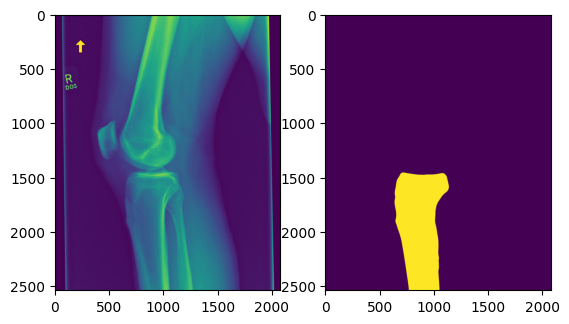

In [153]:
import matplotlib.pyplot as plt

plt.subplot(121); plt.imshow(img)
plt.subplot(122); plt.imshow(mask.squeeze(0)==1)

In [156]:
img_dcm.Laterality

AttributeError: 'FileDataset' object has no attribute 'Laterality'

In [149]:
dir(img_dcm)

['AccessionNumber',
 'AcquisitionContextSequence',
 'AcquisitionDate',
 'AcquisitionNumber',
 'AcquisitionTime',
 'AnatomicRegionSequence',
 'BitsAllocated',
 'BitsStored',
 'BodyPartExamined',
 'BurnedInAnnotation',
 'CollimatorLeftVerticalEdge',
 'CollimatorLowerHorizontalEdge',
 'CollimatorRightVerticalEdge',
 'CollimatorShape',
 'CollimatorUpperHorizontalEdge',
 'Columns',
 'ContentDate',
 'ContentTime',
 'ContrastBolusAgent',
 'DateOfLastDetectorCalibration',
 'DetectorActiveTime',
 'DetectorBinning',
 'DetectorConfiguration',
 'DetectorDescription',
 'DetectorElementPhysicalSize',
 'DetectorElementSpacing',
 'DetectorID',
 'DetectorManufacturerModelName',
 'DetectorManufacturerName',
 'DetectorMode',
 'DetectorTemperature',
 'DetectorType',
 'DeviationIndex',
 'EntranceDose',
 'EntranceDoseInmGy',
 'EthnicGroup',
 'ExposedArea',
 'Exposure',
 'ExposureIndex',
 'ExposureInmAs',
 'ExposureInuAs',
 'ExposureTime',
 'ExposuresOnDetectorSinceLastCalibration',
 'FieldOfViewDimensions',

In [139]:
dir(mask_nrrd)

['CopyInformation',
 'DefaultImageCoordinateTolerance',
 'DefaultImageDirectionTolerance',
 'EraseMetaData',
 'EvaluateAtContinuousIndex',
 'EvaluateAtPhysicalPoint',
 'GetDepth',
 'GetDimension',
 'GetDirection',
 'GetHeight',
 'GetITKBase',
 'GetMetaData',
 'GetMetaDataKeys',
 'GetNumberOfComponentsPerPixel',
 'GetNumberOfPixels',
 'GetOrigin',
 'GetPixel',
 'GetPixelID',
 'GetPixelIDTypeAsString',
 'GetPixelIDValue',
 'GetSize',
 'GetSizeOfPixelComponent',
 'GetSpacing',
 'GetWidth',
 'HasMetaDataKey',
 'IsCongruentImageGeometry',
 'IsSameImageGeometryAs',
 'IsUnique',
 'MakeUnique',
 'SetDirection',
 'SetMetaData',
 'SetOrigin',
 'SetPixel',
 'SetPixelAsComplexFloat64',
 'SetSpacing',
 'ToScalarImage',
 'ToVectorImage',
 'TransformContinuousIndexToPhysicalPoint',
 'TransformIndexToPhysicalPoint',
 'TransformPhysicalPointToContinuousIndex',
 'TransformPhysicalPointToIndex',
 '_Image__imasked_assign',
 '_Image__ipaste',
 '__EvaluateAtContinuousIndex__',
 '__EvaluateAtPhysicalPoint__'